In [22]:
import os
from pathlib import Path

import pytesseract
from PIL import Image
from easyocr import Reader

In [23]:
IMAGE_DIR = os.path.abspath('') + '/data'
IMAGE_PATH = IMAGE_DIR + '/bluebonnet.png'

In [24]:
text = pytesseract.image_to_string(Image.open(IMAGE_PATH), lang='eng')
print(text)

KITCHEN

BEDROOM

DINING ROOM
9x9

LIVING ROOM
14°X 13°

e
\zL

BALCONY ->——_

STORAGE

BLUEBONNET Sisewoom | One Bath



In [25]:
reader = Reader(['en'])
easyocr_text = reader.readtext(IMAGE_PATH)
[result[1] for result in easyocr_text]

/Users/romario/Projects/opencv-playground/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/Users/romario/Projects/opencv-playground/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


['DW',
 '8',
 'BATH',
 'KITCHEN',
 'BEDROOM',
 "11'X 14'",
 'LINEN',
 'DINING ROOM',
 '9\' X 9"',
 'STUDY',
 "10' X 8'",
 'WINDOW SEAT',
 'LIVING ROOM',
 "14'X 13'",
 'WH',
 'BALCONY',
 '1',
 'One Bedroom',
 'One Bath',
 'BLUEBONNET',
 '930 Sq Ft']

In [27]:
from pytesseract import Output

data = pytesseract.image_to_data(Image.open(IMAGE_PATH), lang='eng', output_type=Output.DICT)
pytesseract_boxes = []
for i in range(len(data['text'])):
    word = data['text'][i].strip()
    if not word:
        continue
    x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
    pytesseract_boxes.append({'text': word, 'box': (x, y, x + w, y + h)})
pytesseract_boxes

[{'text': 'KITCHEN', 'box': (643, 170, 724, 184)},
 {'text': 'BEDROOM', 'box': (205, 230, 302, 244)},
 {'text': 'DINING', 'box': (858, 245, 923, 259)},
 {'text': 'ROOM', 'box': (930, 245, 988, 259)},
 {'text': '9x9', 'box': (897, 264, 949, 278)},
 {'text': 'LIVING', 'box': (765, 601, 824, 615)},
 {'text': 'ROOM', 'box': (832, 601, 890, 615)},
 {'text': '14°X', 'box': (792, 620, 833, 635)},
 {'text': '13°', 'box': (841, 620, 864, 635)},
 {'text': 'e', 'box': (1013, 690, 1038, 718)},
 {'text': '\\zL', 'box': (1040, 677, 1055, 718)},
 {'text': 'BALCONY', 'box': (829, 738, 921, 752)},
 {'text': '->——_', 'box': (930, 741, 989, 745)},
 {'text': 'STORAGE', 'box': (1029, 735, 1044, 827)},
 {'text': 'BLUEBONNET', 'box': (235, 886, 462, 917)},
 {'text': 'Sisewoom', 'box': (502, 875, 685, 933)},
 {'text': '|', 'box': (702, 875, 704, 902)},
 {'text': 'One', 'box': (721, 875, 777, 896)},
 {'text': 'Bath', 'box': (787, 876, 843, 896)}]

In [28]:
def quad_to_box(quad):
    xs = [p[0] for p in quad]
    ys = [p[1] for p in quad]
    return (min(xs), min(ys), max(xs), max(ys))

easyocr_boxes = [{'text': text, 'box': quad_to_box(quad)} for quad, text, conf in easyocr_text]
easyocr_boxes

[{'text': 'DW',
  'box': (np.int32(755), np.int32(91), np.int32(789), np.int32(111))},
 {'text': '8',
  'box': (np.int32(132), np.int32(100), np.int32(156), np.int32(182))},
 {'text': 'BATH',
  'box': (np.int32(314), np.int32(140), np.int32(368), np.int32(164))},
 {'text': 'KITCHEN',
  'box': (np.int32(640), np.int32(164), np.int32(728), np.int32(188))},
 {'text': 'BEDROOM',
  'box': (np.int32(203), np.int32(227), np.int32(305), np.int32(247))},
 {'text': "11'X 14'",
  'box': (np.int32(213), np.int32(247), np.int32(293), np.int32(267))},
 {'text': 'LINEN',
  'box': (np.int32(375), np.int32(253), np.int32(431), np.int32(273))},
 {'text': 'DINING ROOM',
  'box': (np.int32(854), np.int32(240), np.int32(992), np.int32(264))},
 {'text': '9\' X 9"',
  'box': (np.int32(893), np.int32(261), np.int32(949), np.int32(281))},
 {'text': 'STUDY',
  'box': (np.int32(496), np.int32(464), np.int32(564), np.int32(488))},
 {'text': "10' X 8'",
  'box': (np.int32(495), np.int32(485), np.int32(563), np.int

In [29]:
import sys

sys.path.append(str(Path(os.path.abspath('')).parent))
from utils.metrics import jaccard_index

# Greedily pair each pytesseract box with the easyocr box it overlaps most.
matches = []
used_easyocr = set()
for p_item in pytesseract_boxes:
    best_iou, best_idx = 0.0, -1
    for idx, e_item in enumerate(easyocr_boxes):
        if idx in used_easyocr:
            continue
        iou = jaccard_index(p_item['box'], e_item['box'])
        if iou > best_iou:
            best_iou, best_idx = iou, idx

    if best_idx != -1 and best_iou > 0:
        used_easyocr.add(best_idx)
        matches.append({'pytesseract_text': p_item['text'], 'easyocr_text': easyocr_boxes[best_idx]['text'], 'iou': best_iou})
    else:
        matches.append({'pytesseract_text': p_item['text'], 'easyocr_text': None, 'iou': 0.0})

for m in matches:
    print(f"{m['iou']:.3f}  pytesseract={m['pytesseract_text']!r:<15} easyocr={m['easyocr_text']!r}")

avg_iou = sum(m['iou'] for m in matches) / len(matches) if matches else 0.0
matched_count = sum(1 for m in matches if m['iou'] > 0)
print(f"\nAverage Jaccard index (matched boxes): {avg_iou:.3f}")
print(f"Pytesseract boxes matched to an easyocr box: {matched_count}/{len(matches)}")
print(f"Easyocr boxes with no pytesseract match: {len(easyocr_boxes) - len(used_easyocr)}/{len(easyocr_boxes)}")

0.537  pytesseract='KITCHEN'       easyocr='KITCHEN'
0.666  pytesseract='BEDROOM'       easyocr='BEDROOM'
0.275  pytesseract='DINING'        easyocr='DINING ROOM'
0.000  pytesseract='ROOM'          easyocr=None
0.650  pytesseract='9x9'           easyocr='9\' X 9"'
0.261  pytesseract='LIVING'        easyocr='LIVING ROOM'
0.000  pytesseract='ROOM'          easyocr=None
0.384  pytesseract='14°X'          easyocr="14'X 13'"
0.000  pytesseract='13°'           easyocr=None
0.294  pytesseract='e'             easyocr='WH'
0.000  pytesseract='\\zL'          easyocr=None
0.548  pytesseract='BALCONY'       easyocr='BALCONY'
0.000  pytesseract='->——_'         easyocr=None
0.587  pytesseract='STORAGE'       easyocr='1'
0.666  pytesseract='BLUEBONNET'    easyocr='BLUEBONNET'
0.452  pytesseract='Sisewoom'      easyocr='One Bedroom'
0.000  pytesseract='|'             easyocr=None
0.283  pytesseract='One'           easyocr='One Bath'
0.000  pytesseract='Bath'          easyocr=None

Average Jaccard inde

/Users/romario/Projects/opencv-playground/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


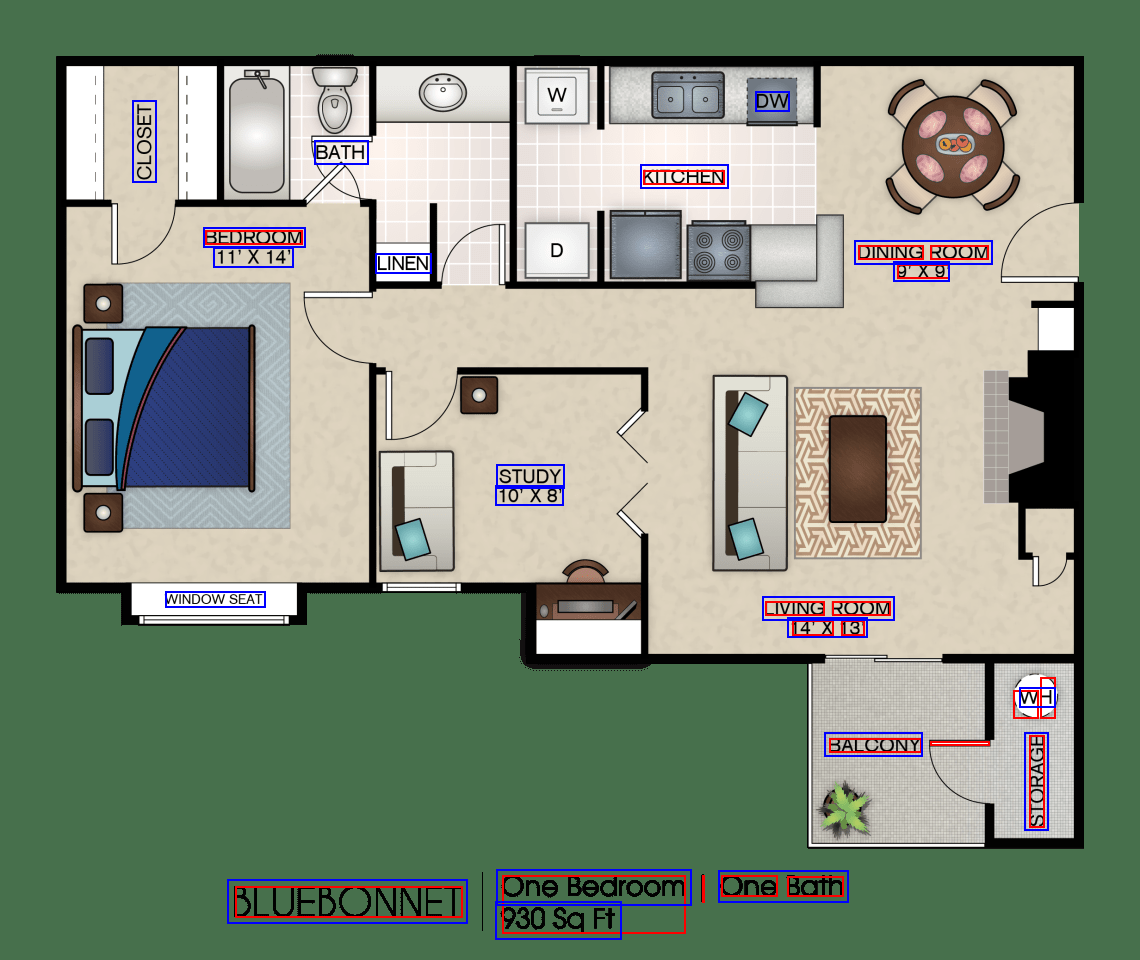

In [30]:
from PIL import ImageDraw

# Visual comparison: pytesseract boxes in red, easyocr boxes in blue.
vis = Image.open(IMAGE_PATH).convert('RGB')
draw = ImageDraw.Draw(vis)

for item in pytesseract_boxes:
    draw.rectangle(item['box'], outline='red', width=2)

for item in easyocr_boxes:
    draw.rectangle(item['box'], outline='blue', width=2)

vis